In [ ]:
import spacy
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
# Download NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [ ]:
# Load spaCy model
nlp = spacy.load("en_core_web_sm")

In [ ]:
# Sample paragraph
text = """Elon Musk founded SpaceX and Tesla.
He was born in South Africa and now lives in the USA.
Microsoft was founded by Bill Gates."""

print("\n--- USING SPACY ---")

# Process text
doc = nlp(text)


--- USING SPACY ---


In [ ]:
# 1️⃣ Group entities by category + Remove duplicates
entities_grouped = defaultdict(set)

for ent in doc.ents:
    entities_grouped[ent.label_].add(ent.text)

print("\nGrouped Entities (No Duplicates):")
for label, ents in entities_grouped.items():
    print(label, ":", list(ents))


Grouped Entities (No Duplicates):
PERSON : ['Bill Gates', 'Elon Musk']
NORP : ['Tesla']
GPE : ['USA', 'South Africa']
ORG : ['Microsoft']


In [ ]:
# 2️⃣ Highlight only specific entity type (e.g., PERSON)
print("\nOnly PERSON entities:")
for ent in doc.ents:
    if ent.label_ == "PERSON":
        print(ent.text)


Only PERSON entities:
Elon Musk
Bill Gates


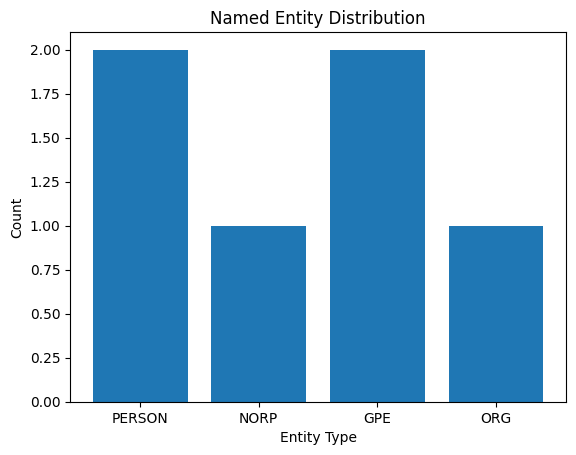

In [ ]:
# 3️⃣ Visualization using bar chart
entity_counts = {label: len(ents) for label, ents in entities_grouped.items()}

plt.bar(entity_counts.keys(), entity_counts.values())
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.title("Named Entity Distribution")
plt.show()

In [ ]:
# 4️⃣ NLTK NER Implementation
# Known corrections
org_keywords = {"Microsoft", "Tesla", "SpaceX", "Google", "Amazon"}

print("\nCorrected NLTK Entities:")

for subtree in tree:
    if hasattr(subtree, 'label'):
        entity = " ".join([leaf[0] for leaf in subtree.leaves()])
        label = subtree.label()

        # Fix common mistakes
        if entity in org_keywords:
            label = "ORGANIZATION"

        print(entity, "->", label)


Corrected NLTK Entities:
Elon -> PERSON
Musk -> PERSON
SpaceX -> ORGANIZATION
Tesla -> ORGANIZATION
South Africa -> GPE
USA -> ORGANIZATION
Microsoft -> ORGANIZATION
Bill Gates -> PERSON
